In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
df = pd.read_csv('C:/Users/ELGRM/OneDrive/Desktop/premier league predictor/data/processed/matches_features.csv')

In [5]:
df.sort_values("Date", ascending= False)

,Season_code,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,...,Away_SoT_For_5,Away_SoT_Against_5,Away_Rest_Days,Away_Cum_Points,Diff_Form_5,Diff_GoalsFor_5,Diff_GoalsAgainst_5,Diff_SoT_For_5,Diff_Rest_Days,Diff_Cum_Points
9139,2627,2026-08-31,Aston Villa,Arsenal,0.0,1.0,A,0.0,0.0,D,...,5.8,1.6,10.0,3.0,-8.0,-0.2,2.0,-1.4,-2.0,-3.0
9138,2627,2026-08-30,Manchester United,Ipswich,5.0,2.0,H,1.0,1.0,D,...,3.6,4.2,8.0,3.0,6.0,0.8,-0.6,1.8,0.0,-3.0
9137,2627,2026-08-30,Sunderland,Fulham,1.0,0.0,H,0.0,0.0,D,...,4.0,5.0,6.0,0.0,4.0,0.4,-0.6,-1.0,2.0,0.0
9136,2627,2026-08-30,Leeds,Brentford,1.0,1.0,D,0.0,1.0,A,...,4.2,6.2,8.0,3.0,2.0,-0.6,-0.2,-0.4,0.0,0.0
9135,2627,2026-08-30,Chelsea,Brighton,4.0,3.0,H,3.0,1.0,H,...,5.2,3.0,7.0,3.0,1.0,0.0,0.4,-1.4,-1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1,1,2000-08-19,Chelsea,West Ham,4.0,2.0,H,1.0,0.0,H,...,NaN,NaN,7.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0
6,1,2000-08-19,Liverpool,Bradford,1.0,0.0,H,0.0,0.0,D,...,NaN,NaN,7.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0
7,1,2000-08-19,Sunderland,Arsenal,1.0,0.0,H,0.0,0.0,D,...,NaN,NaN,7.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0
8,1,2000-08-19,Tottenham Hotspur,Ipswich,3.0,1.0,H,2.0,1.0,H,...,NaN,NaN,7.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0


C:\Users\ELGRM\AppData\Local\Temp\ipykernel_15444\2865072794.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = df , x = 'FTR' , order = ['H' ,'D' ,'A'] , palette= 'viridis')


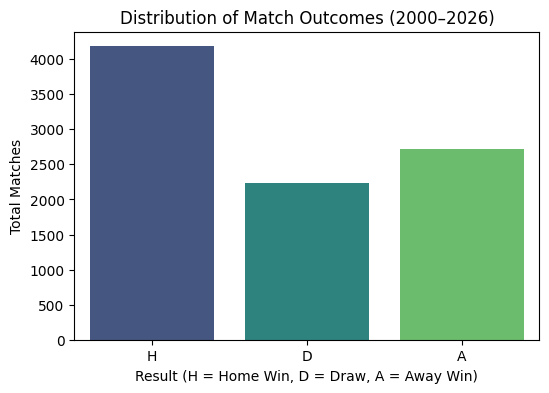

In [4]:
plt.figure(figsize= (6,4))
sns.countplot(data = df , x = 'FTR' , order = ['H' ,'D' ,'A'] , palette= 'viridis')
plt.title('Distribution of Match Outcomes (2000–2026)')

plt.xlabel('Result (H = Home Win, D = Draw, A = Away Win)')
plt.ylabel('Total Matches')
plt.show()


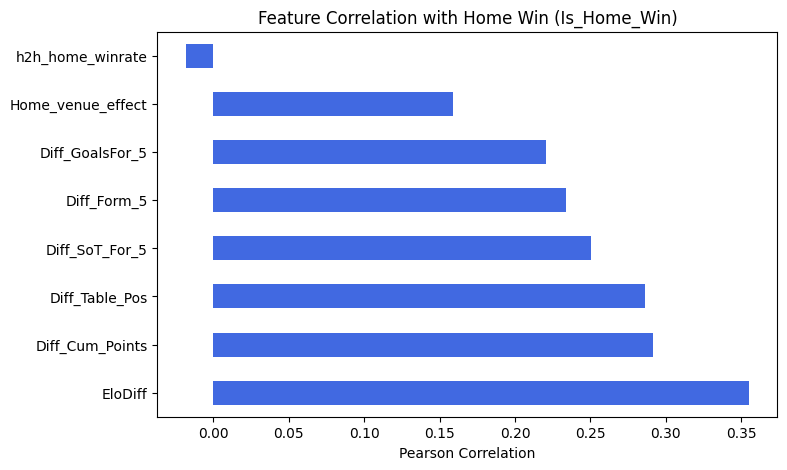

In [7]:
df['is_Home_win'] = (df['FTR'] == 'H').astype(int)

features_to_check = [
    'EloDiff', 'Diff_Form_5', 'Diff_Table_Pos', 'Diff_GoalsFor_5',
    'Diff_SoT_For_5', 'Diff_Cum_Points', 'h2h_home_winrate', 'Home_venue_effect'
]

correlations = df[features_to_check].apply(lambda x:x.corr(df['is_Home_win'])).sort_values(ascending = False)

plt.figure(figsize=(8, 5))
correlations.plot(kind='barh', color='royalblue')
plt.title('Feature Correlation with Home Win (Is_Home_Win)')
plt.xlabel('Pearson Correlation')
plt.show()

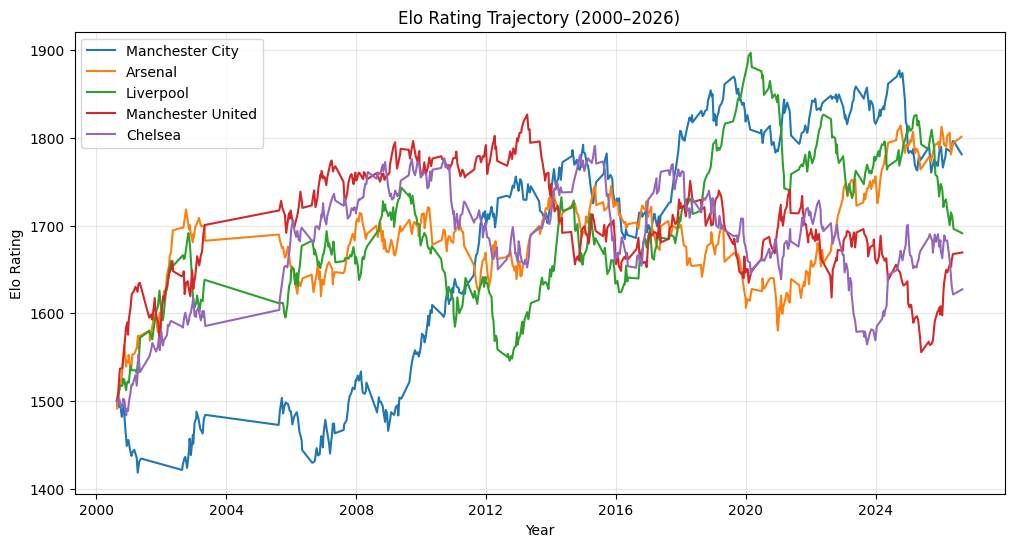

In [8]:
plt.figure(figsize=(12, 6))
top_teams = ['Manchester City', 'Arsenal', 'Liverpool', 'Manchester United', 'Chelsea']
# Re-read or plot team Elo from df
for team in top_teams:
    team_matches = df[df['HomeTeam'] == team][['Date', 'HomeElo']].rename(columns={'HomeElo': 'Elo'})
    plt.plot(pd.to_datetime(team_matches['Date']), team_matches['Elo'], label=team)
plt.title('Elo Rating Trajectory (2000–2026)')
plt.xlabel('Year')
plt.ylabel('Elo Rating')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

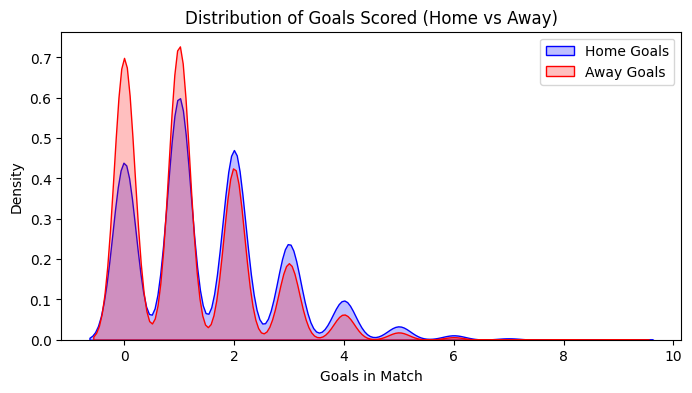

In [9]:
plt.figure(figsize=(8, 4))
sns.kdeplot(df['FTHG'], label='Home Goals', fill=True, color='blue')
sns.kdeplot(df['FTAG'], label='Away Goals', fill=True, color='red')
plt.title('Distribution of Goals Scored (Home vs Away)')
plt.xlabel('Goals in Match')
plt.legend()
plt.show()